In [1]:
""" 

OpenTopography DEM -> Landlab RasterModelGrid -> NetworkModelGrid 

Bbox from your polygon ([lon, lat]): lon 11.4505-14.0194, lat 46-47  (Tyrol / Eastern Alps) 

 

pip install landlab bmi-topography rasterio rioxarray richdem matplotlib 

""" 

import os 

 

import matplotlib.pyplot as plt 
import pyproj as pp
import numpy as np 

import xarray as xr 

from bmi_topography import Topography 

from rasterio.warp import Resampling, calculate_default_transform, reproject 

 

from landlab import RasterModelGrid, imshow_grid 

from landlab.components import PriorityFloodFlowRouter 

from landlab.grid.create_network import network_grid_from_raster 

from landlab.plot.graph import plot_links, plot_nodes 

 

# --- config --------------------------------------------------------------- 

API_KEY = os.environ.get("OPENTOPOGRAPHY_API_KEY", "5555922bf1202c4030f232561cca617a") 

NODATA = -9999 

RES = 90  # m; ~native SRTMGL3. Use SRTMGL1 + RES=30 for finer (bigger download). 

UTM_CRS = "EPSG:32633"  # UTM 33N - bbox centre ~12.7E, zone 33 spans 12-18E 

MIN_CHANNEL_AREA = 50e6  # m^2 upstream area to start a channel; start high, lower for more detail 

 

# --- 1. download ----------------------------------------------------------- 

dem = Topography( 

    north=47.0, 

    south=46.0, 

    east=14.0194, 

    west=11.4505, 

    output_format="AAIGrid", 

    dem_type="SRTMGL3", 

    cache_dir=".bmi_topography", 

    api_key=API_KEY,  # fixed: your original had a leading space in the key string 

) 

dem.load() 

 

# --- 2. reproject WGS84 -> UTM --------------------------------------------- 

src_crs = "EPSG:4326" 

transform, nx, ny = calculate_default_transform( 

    src_crs, 

    UTM_CRS, 

    len(dem.da["x"]), 

    len(dem.da["y"]), 

    left=dem.bbox.west, 

    bottom=dem.bbox.south, 

    right=dem.bbox.east, 

    top=dem.bbox.north, 

    resolution=RES, 

) 

# cell-centre coords straight from the affine (row 0 = north edge) 

x_utm = transform.c + transform.a * (np.arange(nx) + 0.5) 

y_utm = transform.f + transform.e * (np.arange(ny) + 0.5) 

 

out = xr.DataArray( 

    np.empty((1, ny, nx), dtype="float32"), 

    dims=["band", "y", "x"], 

    coords={"band": [1], "y": y_utm, "x": x_utm}, 

) 

arr, _ = reproject( 

    dem.da, 

    out, 

    src_transform=dem.da.rio.transform(), 

    src_crs=src_crs, 

    src_nodata=dem.da.rio.nodata, 

    dst_transform=transform, 

    dst_crs=UTM_CRS, 

    dst_nodata=NODATA, 

    resampling=Resampling.nearest, 

) 

 

# --- 3. Landlab RasterModelGrid -------------------------------------------- 

grid = RasterModelGrid( 

    (ny, nx), 

    xy_spacing=RES, 

    xy_of_lower_left=(x_utm[0], y_utm[-1]),  # lower-left = last (southern) row 

    xy_axis_name=("X UTM33", "Y UTM33"), 

    xy_axis_units="m", 

) 

z = np.flipud(np.asarray(arr).squeeze()).ravel().astype(float)  # Landlab node 0 is SW corner 

grid.at_node["topographic__elevation"] = z 

grid.status_at_node[np.isclose(z, NODATA)] = grid.BC_NODE_IS_CLOSED 

print(f"grid: {ny} x {nx} = {grid.number_of_nodes:,} nodes") 

 

# --- 4. visualize the DEM --------------------------------------------------- 

fig, ax = plt.subplots(figsize=(8, 6)) 

imshow_grid( 

    grid, 

    "topographic__elevation", 

    plot_name="Topographic Elevation (UTM33)", 

    var_name="Elevation", 

    var_units="m", 

    cmap="terrain", 

    grid_units=("m", "m"), 

) 

plt.tight_layout() 

plt.savefig("dem_elevation.png", dpi=150) 

plt.close(fig) 



/opt/tljh/user/envs/ivy/lib/python3.13/site-packages/bmi_topography/topography.py:255: UserWarning: A CRS cannot be identified for these data. Grid units will be set to 'unknown'.
  warnings.warn(


grid: 1298 x 2226 = 2,889,348 nodes


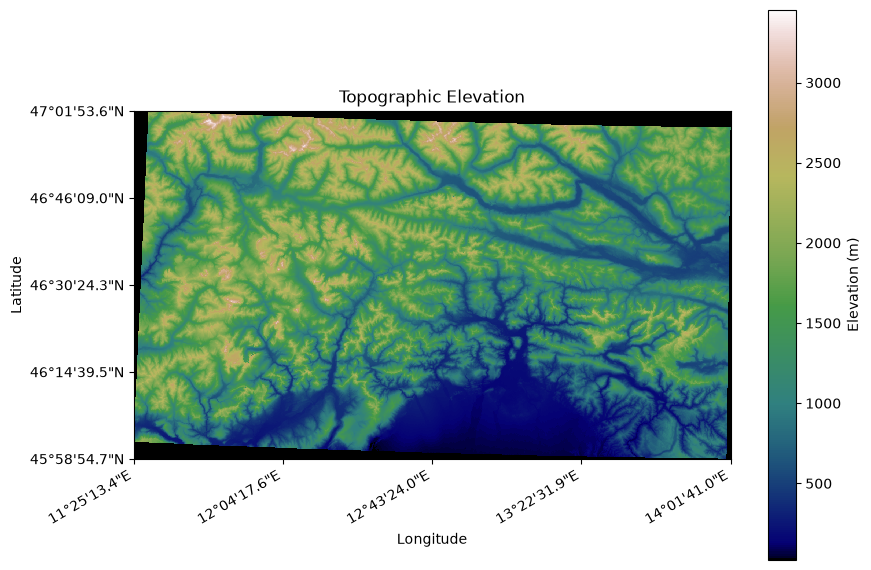

/opt/tljh/user/envs/ivy/lib/python3.13/site-packages/bmi_topography/topography.py:255: UserWarning: A CRS cannot be identified for these data. Grid units will be set to 'unknown'.
  warnings.warn(


grid: 1298 x 2226 = 2,889,348 nodes


In [2]:
#only for visualization
import pyproj 

 

def decimal_to_dms(deg, is_lat): 

    hemi = ("N" if deg >= 0 else "S") if is_lat else ("E" if deg >= 0 else "W") 

    deg = abs(deg) 

    d = int(deg) 

    m_full = (deg - d) * 60 

    m = int(m_full) 

    s = (m_full - m) * 60 

    return f"{d}\u00b0{m:02d}'{s:04.1f}\"{hemi}" 

 

transformer = pyproj.Transformer.from_crs(UTM_CRS, "EPSG:4326", always_xy=True) 

 

fig, ax = plt.subplots(figsize=(9, 6)) 

imshow_grid( 

    grid, 

    "topographic__elevation", 

    plot_name="Topographic Elevation", 

    var_name="Elevation", 

    var_units="m", 

    cmap="gist_earth", 

    grid_units=("m", "m"), 

) 

 

# pick tick positions in UTM metres (5 ticks per axis is usually readable) 

x_ticks = np.linspace(x_utm.min(), x_utm.max(), 5) 

y_ticks = np.linspace(y_utm.min(), y_utm.max(), 5) 

 

# convert each axis's ticks to lon/lat, holding the other coordinate at 

# the map's centre (since UTM->lonlat is not separable, this is an 

# approximation good enough for tick labels, not exact per-point conversion) 

lon_ticks, _ = transformer.transform(x_ticks, np.full_like(x_ticks, y_utm.mean())) 

_, lat_ticks = transformer.transform(np.full_like(y_ticks, x_utm.mean()), y_ticks) 

 

ax.set_xticks(x_ticks) 

ax.set_xticklabels([decimal_to_dms(lon, is_lat=False) for lon in lon_ticks], rotation=30, ha="right") 

ax.set_yticks(y_ticks) 

ax.set_yticklabels([decimal_to_dms(lat, is_lat=True) for lat in lat_ticks]) 

ax.set_xlabel("Longitude") 

ax.set_ylabel("Latitude") 

 

plt.tight_layout() 

plt.show() 

""" 

OpenTopography DEM -> Landlab RasterModelGrid -> NetworkModelGrid 

Bbox from your polygon ([lon, lat]): lon 11.4505-14.0194, lat 46-47  (Tyrol / Eastern Alps) 

 

pip install landlab bmi-topography rasterio rioxarray richdem matplotlib 

""" 

#import os 

 

#import matplotlib.pyplot as plt 

#import numpy as np 

#import xarray as xr 

#from bmi_topography import Topography 

#from rasterio.warp import Resampling, calculate_default_transform, reproject 

 

#from landlab import RasterModelGrid, imshow_grid 

#from landlab.components import PriorityFloodFlowRouter 

#from landlab.grid.create_network import network_grid_from_raster 

#from landlab.plot.graph import plot_links, plot_nodes 

 

# --- config --------------------------------------------------------------- 

API_KEY = os.environ.get("OPENTOPOGRAPHY_API_KEY", "5555922bf1202c4030f232561cca617a") 

NODATA = -9999 

RES = 90  # m; ~native SRTMGL3. Use SRTMGL1 + RES=30 for finer (bigger download). 

UTM_CRS = "EPSG:32633"  # UTM 33N - bbox centre ~12.7E, zone 33 spans 12-18E 

MIN_CHANNEL_AREA = 50e6  # m^2 upstream area to start a channel; start high, lower for more detail 

 

# --- 1. download ----------------------------------------------------------- 

dem = Topography( 

    north=47.0, 

    south=46.0, 

    east=14.0194, 

    west=11.4505, 

    output_format="AAIGrid", 

    dem_type="SRTMGL3", 

    cache_dir=".bmi_topography", 

    api_key=API_KEY,  # fixed: your original had a leading space in the key string 

) 

dem.load() 

 

# --- 2. reproject WGS84 -> UTM --------------------------------------------- 

src_crs = "EPSG:4326" 

transform, nx, ny = calculate_default_transform( 

    src_crs, 

    UTM_CRS, 

    len(dem.da["x"]), 

    len(dem.da["y"]), 

    left=dem.bbox.west, 

    bottom=dem.bbox.south, 

    right=dem.bbox.east, 

    top=dem.bbox.north, 

    resolution=RES, 

) 

# cell-centre coords straight from the affine (row 0 = north edge) 

x_utm = transform.c + transform.a * (np.arange(nx) + 0.5) 

y_utm = transform.f + transform.e * (np.arange(ny) + 0.5) 

 

out = xr.DataArray( 

    np.empty((1, ny, nx), dtype="float32"), 

    dims=["band", "y", "x"], 

    coords={"band": [1], "y": y_utm, "x": x_utm}, 

) 

arr, _ = reproject( 

    dem.da, 

    out, 

    src_transform=dem.da.rio.transform(), 

    src_crs=src_crs, 

    src_nodata=dem.da.rio.nodata, 

    dst_transform=transform, 

    dst_crs=UTM_CRS, 

    dst_nodata=NODATA, 

    resampling=Resampling.nearest, 

) 

 

# --- 3. Landlab RasterModelGrid -------------------------------------------- 

grid = RasterModelGrid( 

    (ny, nx), 

    xy_spacing=RES, 

    xy_of_lower_left=(x_utm[0], y_utm[-1]),  # lower-left = last (southern) row 

    xy_axis_name=("X UTM33", "Y UTM33"), 

    xy_axis_units="m", 

) 

z = np.flipud(np.asarray(arr).squeeze()).ravel().astype(float)  # Landlab node 0 is SW corner 

grid.at_node["topographic__elevation"] = z 

grid.status_at_node[np.isclose(z, NODATA)] = grid.BC_NODE_IS_CLOSED 

print(f"grid: {ny} x {nx} = {grid.number_of_nodes:,} nodes") 

 

# --- 4. visualize the DEM --------------------------------------------------- 

fig, ax = plt.subplots(figsize=(8, 6)) 

imshow_grid( 

    grid, 

    "topographic__elevation", 

    plot_name="Topographic Elevation (UTM33)", 

    var_name="Elevation", 

    var_units="m", 

    cmap="terrain", 

    grid_units=("m", "m"), 

) 

plt.tight_layout() 

plt.savefig("dem_elevation.png", dpi=150) 

plt.close(fig) 

In [3]:
# start by importing necessary modules
import matplotlib.pyplot as plt
import numpy as np
#import pyproj as pp

from landlab import HexModelGrid, RasterModelGrid
from landlab.components import FastscapeEroder, FlowAccumulator, NormalFault, ChannelProfiler
from landlab.plot import imshow_grid

%matplotlib inline

Fault trace in UTM33N: (229521.6, 5197214.2) -> (424816.2, 5154848.4)


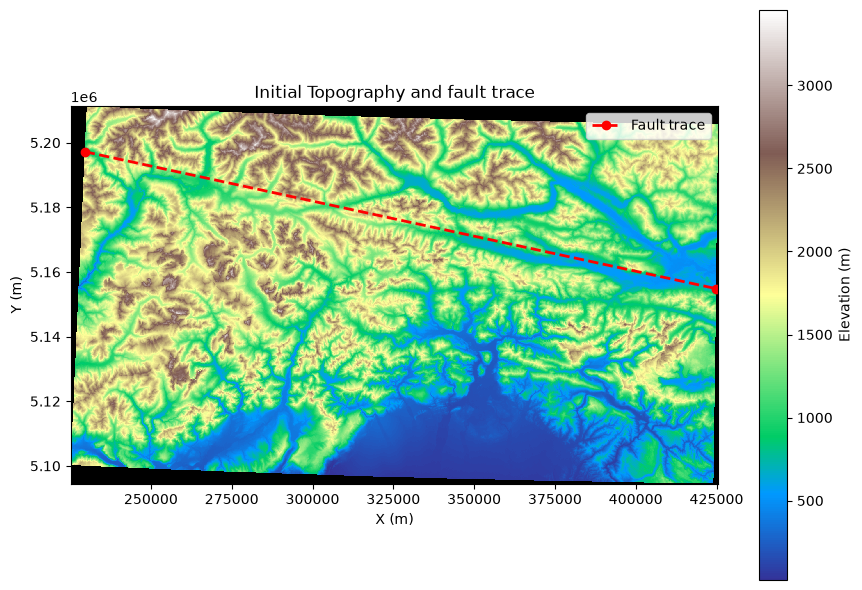

In [4]:
# --- config ----------------------------------------------------------- 

UTM_CRS = "EPSG:32633"   # must match the CRS your existing `grid` was built in 

#K_sp = 1e-5              # stream-power erodibility coefficient 

#U = 1e-3                 # m/yr; uplift rate applied to core nodes each step 

#DT = 1000.0              # yr; timestep 

#N_STEPS = 20             # 20 steps x 1000 yr = 20,000 yr total 

# here are the parameters to change
K = 0.0005  # stream power coefficient, bigger = streams erode more quickly
U = 0.0025  # uplift rate in meters per year

dt = 1000  # time step in years


# --- 1. convert fault trace endpoints lon/lat -> UTM33 ----------------- 

V1 = [11.4505, 46.8734] 

V2 = [14.0194, 46.5430] 

  

transformer = pyproj.Transformer.from_crs("EPSG:4326", UTM_CRS, always_xy=True) 

x1_utm, y1_utm = transformer.transform(V1[0], V1[1]) 

x2_utm, y2_utm = transformer.transform(V2[0], V2[1]) 

print(f"Fault trace in UTM33N: ({x1_utm:.1f}, {y1_utm:.1f}) -> ({x2_utm:.1f}, {y2_utm:.1f})") 

  

# --- 2. get the existing elevation field --------------------------------- 

z = grid.at_node["topographic__elevation"]
z_init = z.copy()

# --- 3. components -------------------------------------------------------- 

#fr = FlowAccumulator(grid, flow_director="D8") 

#fs = FastscapeEroder(grid, K_sp=K) 

nf = NormalFault( 

    grid, 

    faulted_surface="topographic__elevation", 

    fault_trace={"x1": x1_utm, "y1": y1_utm, "x2": x2_utm, "y2": y2_utm}, 

    include_boundaries=True, 

) 

  

#--- 4. run for 20 x 1000-yr timesteps (20,000 yr total) ------------------ 

#for i in range(N_STEPS): 

 #  nf.run_one_step(dt=DT) 

 #   fr.run_one_step() 

 #   fs.run_one_step(dt=DT) 

   ## z[grid.core_nodes] += U * DT 

  

#print(f"Ran {N_STEPS} steps of {DT:.0f} yr = {N_STEPS * DT:,.0f} yr total") 

  

# --- 5. plot final topography ---------------------------------------------- 

fig, ax = plt.subplots(figsize=(9, 6)) 

imshow_grid( 

    grid, 

    "topographic__elevation", 

    plot_name="Initial Topography and fault trace", 

    var_name="Elevation", 

    var_units="m", 

    cmap="terrain", 

    grid_units=("m", "m"), 

) 

ax.plot( 

    [x1_utm, x2_utm], 

    [y1_utm, y2_utm], 

    color="red", 

    linewidth=2, 

    linestyle="--", 

    marker="o", 

    markersize=6, 

    label="Fault trace", 

) 

ax.legend(loc="upper right") 


plt.tight_layout() 

plt.show()

/opt/tljh/user/envs/ivy/lib/python3.13/site-packages/landlab/graph/sort/sort.py:724: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  angle_of_spoke_at_hub = np.arctan2(dy, dx, where=spokes_at_hub != -1)


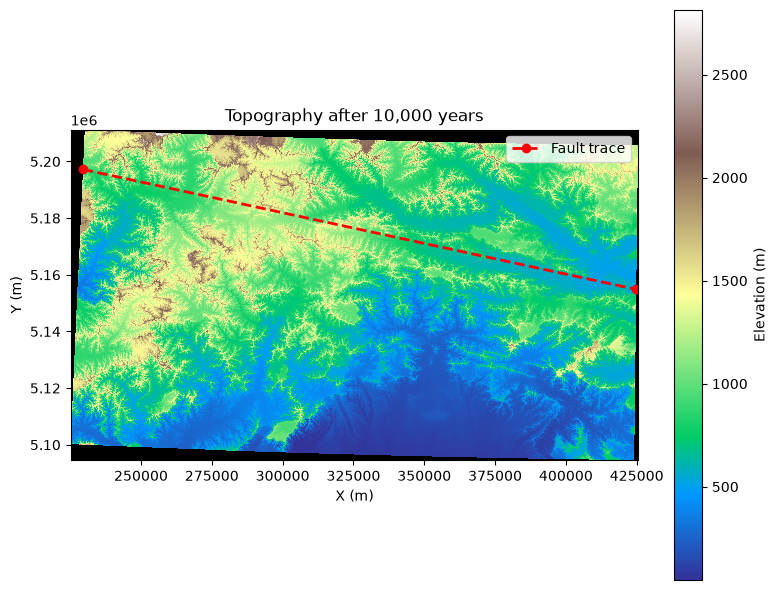

In [5]:
# instantiate the grid
#grid = "topographic__elevation"
# add a topographic__elevation field with noise
#z = grid.add_zeros("topographic__elevation", at="node")
#z[grid.core_nodes] += 100.0 + np.random.randn(grid.core_nodes.size)

#fr = FlowAccumulator(grid)
#fs = FastscapeEroder(grid, K_sp=K)
#nf = NormalFault(
    #grid, fault_trace={"x1": x1_utm, "y1": y1_utm, "x2": x2_utm, "y2": y2_utm}, include_boundaries=True
#)

# Run this model for 20 1000-year timesteps (20_000 years).

fr = FlowAccumulator(grid, flow_director="D8") 

fs = FastscapeEroder(grid, K_sp=K) 

for i in range(10):
    fr.run_one_step()
    fs.run_one_step(dt)
    z[grid.core_nodes] += U * dt

# plot the topography
# --- 4. visualize the DEM --------------------------------------------------- 

fig, ax = plt.subplots(figsize=(8, 6)) 

imshow_grid( 

    grid, 

    "topographic__elevation", 

    plot_name="Topography after 10,000 years", 

    var_name="Elevation", 

    var_units="m", 

    cmap="terrain", 

    grid_units=("m", "m"), 

) 




ax.plot( 

    [x1_utm, x2_utm], 

    [y1_utm, y2_utm], 

    color="red", 

    linewidth=2, 

    linestyle="--", 

    marker="o", 

    markersize=6, 

    label="Fault trace", 

) 

ax.legend(loc="upper right") 
plt.tight_layout() 

plt.show()


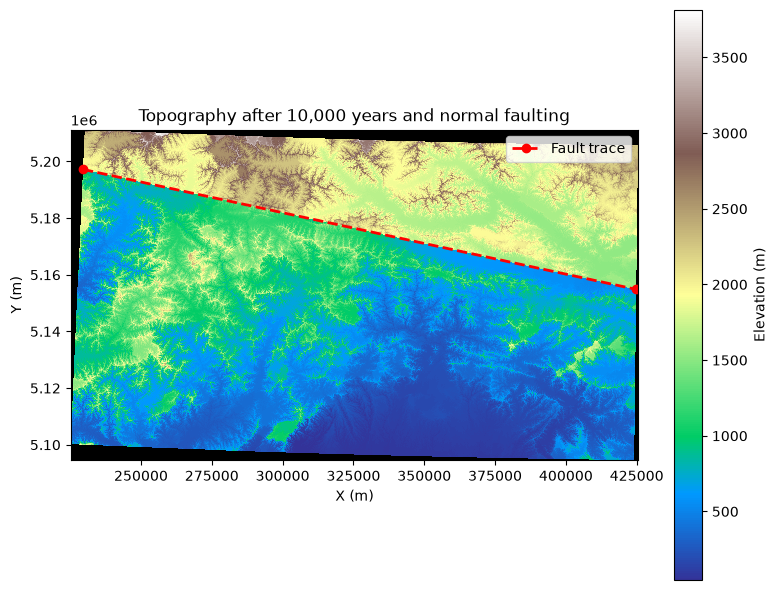

In [6]:
# Earthquake with 200 m displacement    
nf.run_one_earthquake(dz=1000)

# plot the  topography
fig, ax = plt.subplots(figsize=(8, 6)) 

imshow_grid( 

    grid, 

    "topographic__elevation", 

    plot_name="Topography after 10,000 years and normal faulting", 

    var_name="Elevation", 

    var_units="m", 

    cmap="terrain", 

    grid_units=("m", "m"), 

) 

ax.plot( 

    [x1_utm, x2_utm], 

    [y1_utm, y2_utm], 

    color="red", 

    linewidth=2, 

    linestyle="--", 

    marker="o", 

    markersize=6, 

    label="Fault trace", 

) 

ax.legend(loc="upper right") 
plt.tight_layout() 

plt.show()

In [ ]:
# Run this model again for 20 1000-year timesteps (20_000 years).
for i in range(10):
   fr.run_one_step()
   fs.run_one_step(dt)
   z[grid.core_nodes] += U * dt
    
# plot the  topography
fig, ax = plt.subplots(figsize=(8, 6)) 

imshow_grid( 

    grid, 

    "topographic__elevation", 

    plot_name="Final Topography", 

    var_name="Elevation", 

    var_units="m", 

    cmap="terrain", 

    grid_units=("m", "m"), 

) 

ax.plot( 

    [x1_utm, x2_utm], 

    [y1_utm, y2_utm], 

    color="red", 

    linewidth=2, 

    linestyle="--", 

    marker="o", 

    markersize=6, 

    label="Fault trace", 

) 

ax.legend(loc="upper right") 
plt.tight_layout() 

plt.show()